# Lab 06：在 MNIST 上訓練影像 DDPM

對應講義：[第 06 課](../lessons/06_unet_image_diffusion.md)

演算法和 Lab 04 **一模一樣**（同一個 `ddpm_loss`、同一個 `ddpm_sample`），只把 MLP 換成 U-Net、把 2D 點換成 28×28 的數字。

1. 看 U-Net 的規模與時間嵌入長什麼樣
2. 訓練，並比較 EMA 權重與原始權重的樣本
3. 看一張數字如何從雜訊中「顯影」，以及每一步的 $\hat x_0$
4. 用小分類器量化品質；檢查有沒有「背下」訓練資料
5. 存檔：Lab 07 會直接載入這個模型

**執行時間**：下面的設定在 4 核心 CPU 上單獨執行時訓練約 16 分鐘（本 notebook 存下的輸出是與其他工作共用 CPU 時跑的，紀錄為 24 分鐘）。有 GPU 的話，建議把 `BASE_CHANNELS` 改成 32、`TRAIN_STEPS` 改成 10000 以上，`EMA_DECAY` 改成 0.999。

In [1]:
import matplotlib.pyplot as plt
import torch

from diffusion_course.utils import get_device, notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)
device = get_device()
print(f"torch {torch.__version__} on {device}")

torch 2.14.0+cpu on cpu


In [2]:
BASE_CHANNELS = 16
TRAIN_STEPS = 2000
BATCH_SIZE = 128
LEARNING_RATE = 1e-3
EMA_DECAY = 0.995

## 1. 資料、模型、時間嵌入

U-Net with 305,681 parameters
input (2, 1, 28, 28) -> output (2, 1, 28, 28)


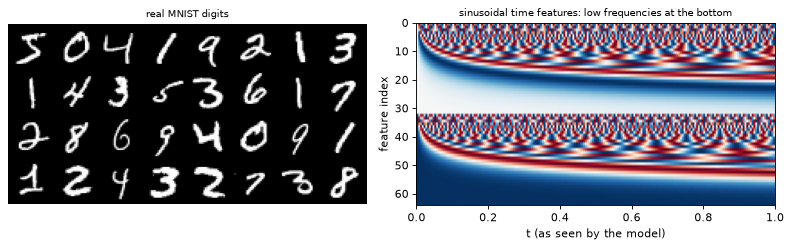

In [3]:
from diffusion_course.data import image_dataset, image_loader, infinite_batches
from diffusion_course.models import UNet
from diffusion_course.utils import count_parameters
from diffusion_course.viz import show_images

train_set = image_dataset("mnist", train=True)
real = torch.stack([train_set[i][0] for i in range(64)])

model = UNet(in_channels=1, base_channels=BASE_CHANNELS)
print(f"U-Net with {count_parameters(model):,} parameters")
print("input", tuple(real[:2].shape), "-> output", tuple(model(real[:2], torch.rand(2)).shape))

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
show_images(real[:32], axes[0], title="real MNIST digits")
features = model.time_embed.net[0](torch.linspace(0, 1, 200))  # the sinusoidal part
axes[1].imshow(features.T, aspect="auto", cmap="RdBu", extent=(0, 1, features.shape[1], 0))
axes[1].set_xlabel("t (as seen by the model)")
axes[1].set_ylabel("feature index")
axes[1].set_title("sinusoidal time features: low frequencies at the bottom", fontsize=9)
plt.tight_layout()
plt.show()

## 2. 訓練

和 Lab 04 相同的一行 `train(...)`。注意 `ema_decay`：只訓練 2000 步，用 0.995（記憶長度約 200 步）。

step 250/2000  loss 0.1114


step 500/2000  loss 0.0331


step 750/2000  loss 0.0303


step 1000/2000  loss 0.0287


step 1250/2000  loss 0.0273


step 1500/2000  loss 0.0268


step 1750/2000  loss 0.0262


step 2000/2000  loss 0.0259


trained 2000 steps in 24.4 min


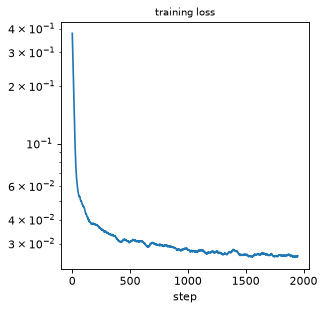

In [4]:
from diffusion_course.ddpm import ddpm_loss
from diffusion_course.schedules import NoiseSchedule
from diffusion_course.training import train
from diffusion_course.viz import new_axes, plot_loss

schedule = NoiseSchedule.create("linear", 1000).to(device)
result = train(
    model,
    lambda m, x, y: ddpm_loss(m, schedule, x),  # labels are ignored: unconditional model
    infinite_batches(image_loader("mnist", BATCH_SIZE)),
    num_steps=TRAIN_STEPS,
    lr=LEARNING_RATE,
    ema_decay=EMA_DECAY,
    device=device,
    log_every=250,
)
ema_model = result.sampling_model
print(f"trained {TRAIN_STEPS} steps in {result.seconds / 60:.1f} min")
(ax,) = new_axes(1, size=4)
plot_loss(result.losses, ax, window=50)
plt.show()

## 3. 取樣：EMA vs. 原始權重

同一份起始雜訊，1000 步 DDPM，`clip_x0=True`（講義 §2.4）。

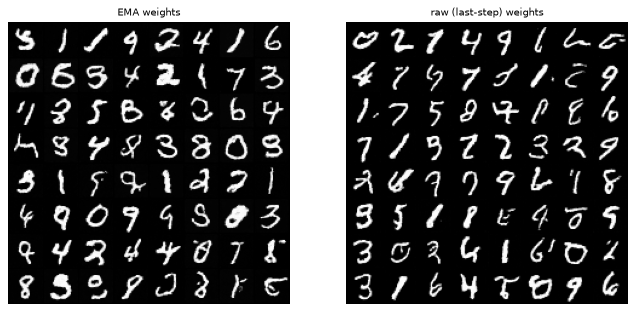

In [5]:
from diffusion_course.ddpm import ddpm_sample

noise = torch.randn(64, 1, 28, 28, device=device)
ema_samples = ddpm_sample(ema_model, schedule, noise.shape, noise=noise, clip_x0=True)
raw_samples = ddpm_sample(model, schedule, noise.shape, noise=noise, clip_x0=True)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
show_images(ema_samples, axes[0], title="EMA weights")
show_images(raw_samples, axes[1], title="raw (last-step) weights")
plt.show()

## 4. 顯影過程

8 個樣本，上面一組是反向過程中的 $x_t$，下面一組是每一步網路心中的 $\hat x_0$（Tweedie 條件平均）。
最左兩欄的 $\hat x_0$ 看起來還像雜訊：和 Lab 04 一樣，由 $\hat\epsilon$ 換算時要除以很小的 $\sqrt{\bar\alpha_t}$，誤差被放大（這裡已截在 $[-1, 1]$）。
從 $t \approx 600$ 起，$\hat x_0$ 是一團模糊的「平均數字」；到 $t \approx 400$ 形狀已經決定，之後只是把細節補清楚。

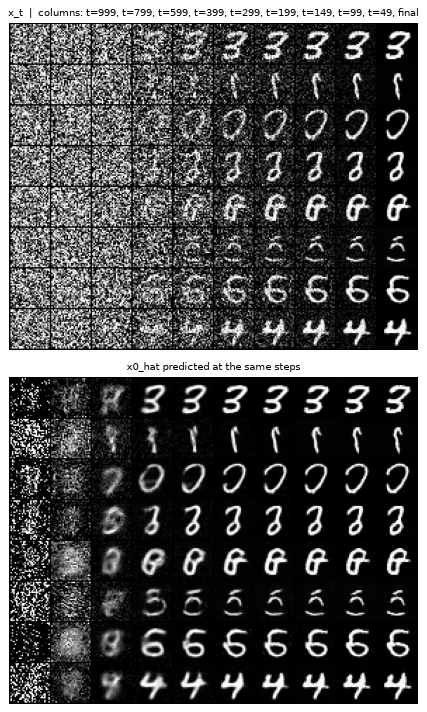

In [6]:
from diffusion_course.ddpm import predict_x0

SAVE_EVERY = 50
eight_noise = torch.randn(8, 1, 28, 28, device=device)
_, trajectory = ddpm_sample(ema_model, schedule, eight_noise.shape, noise=eight_noise, clip_x0=True, save_every=SAVE_EVERY)
levels = [999] + [1000 - SAVE_EVERY * k - 1 for k in range(1, len(trajectory))]
shown = [0, 4, 8, 12, 14, 16, 17, 18, 19, 20]  # trajectory indices

states, x0_hats = [], []
for k in shown:
    state = trajectory[k]
    states.append(state)
    if levels[k] >= 0:
        t = torch.full((len(state),), levels[k], device=device)
        with torch.no_grad():
            x0_hats.append(predict_x0(schedule, state, t, ema_model(state, schedule.timestep_input(t))).clamp(-1, 1))
    else:
        x0_hats.append(state)

fig, axes = plt.subplots(2, 1, figsize=(10, 9))
titles = [("final" if levels[k] < 0 else f"t={levels[k]}") for k in shown]
show_images(torch.stack(states, dim=1).flatten(0, 1), axes[0], nrow=len(shown), title="x_t  |  columns: " + ", ".join(titles))
show_images(torch.stack(x0_hats, dim=1).flatten(0, 1), axes[1], nrow=len(shown), title="x0_hat predicted at the same steps")
plt.tight_layout()
plt.show()

## 5. 用分類器量化品質

`get_digit_classifier` 第一次呼叫時會訓練一個小 CNN（約 1 分鐘）並存到 `checkpoints/`，之後的實驗直接載入。

In [7]:
from diffusion_course.evaluation import get_digit_classifier, judge_samples

classifier = get_digit_classifier(device)
test_set = image_dataset("mnist", train=False)
test_images = torch.stack([test_set[i][0] for i in range(1000)])
test_labels = torch.tensor([test_set[i][1] for i in range(1000)])
print("classifier accuracy on real test digits:", judge_samples(classifier, test_images, test_labels)["accuracy"])

more_ema = ddpm_sample(ema_model, schedule, (256, 1, 28, 28), clip_x0=True)
more_raw = ddpm_sample(model, schedule, (256, 1, 28, 28), clip_x0=True)
print("real test digits :", judge_samples(classifier, test_images[:256]))
print("EMA samples      :", judge_samples(classifier, more_ema))
print("raw samples      :", judge_samples(classifier, more_raw))

classifier accuracy on real test digits: 0.9810000061988831


real test digits : {'confidence': 0.9853226542472839, 'class_entropy': 0.986824056010982}
EMA samples      : {'confidence': 0.9007529020309448, 'class_entropy': 0.9890194967562868}
raw samples      : {'confidence': 0.8912760615348816, 'class_entropy': 0.9682822475337283}


## 6. 有沒有背下訓練資料？

對每個生成樣本，在 2 萬張訓練圖裡找 L2 距離最近的一張。如果模型只是在「背書」，兩者會幾乎一模一樣。

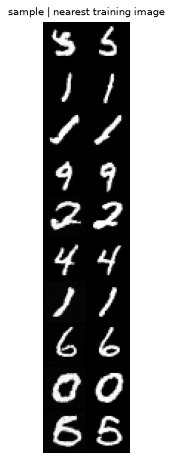

mean distance sample -> nearest training image : 10.07
for comparison, training image -> nearest other : 7.99


In [8]:
reference = torch.stack([train_set[i][0] for i in range(20_000)]).flatten(1)
queries = ema_samples[:10].cpu().flatten(1)
distances = torch.cdist(queries, reference)
nearest = distances.argmin(dim=1)
pairs = torch.stack([ema_samples[:10].cpu(), reference[nearest].reshape(-1, 1, 28, 28)], dim=1).flatten(0, 1)

fig, ax = plt.subplots(figsize=(3, 7))
show_images(pairs, ax, nrow=2, title="sample | nearest training image")
plt.show()
train_pair_distance = torch.cdist(reference[:10], reference[10:]).min(dim=1).values.mean()
print(f"mean distance sample -> nearest training image : {distances.min(dim=1).values.mean():.2f}")
print(f"for comparison, training image -> nearest other : {train_pair_distance:.2f}")

生成的數字和最接近的訓練圖**相似但不相同**，距離和「兩張不同的真實訓練圖」之間的距離同一個量級：這個小模型在學「數字的樣子」，而不是背圖。
（大型文生圖模型就不一定了，見講義 §2.6。）

## 7. 存檔，給 Lab 07 用

In [9]:
from diffusion_course.training import save_checkpoint
from diffusion_course.utils import CHECKPOINT_DIR

save_checkpoint(
    CHECKPOINT_DIR / "lab06_mnist_ddpm_unet.pt",
    ema_model,
    arch="unet",
    model_kwargs={"in_channels": 1, "base_channels": BASE_CHANNELS},
    method="ddpm",
    schedule="linear",
    dataset="mnist",
    num_classes=None,
)

saved checkpoint to checkpoints/lab06_mnist_ddpm_unet.pt


## 小結

- 影像擴散 = 同樣的演算法 ＋ U-Net。
- EMA 權重的樣本筆畫較完整；分類器指標也略好，但只訓練 2000 步時差距不大（訓練越久、學習率越大，EMA 的效果越明顯）。
- 形狀在高雜訊階段就決定了，細節在最後才出現。
- 只訓練 2000 步的小模型已經生成得出可辨認的數字，而且不是在背訓練資料。

下一課：同一個模型，能不能不要跑 1000 步？